In [66]:
import pandas as pd

fear=pd.read_csv("fear.csv")
trades=pd.read_csv("trades.csv")

fear.info()
trades.info()
fear.head()
trades.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-nu

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [67]:
fear.isnull().sum()
trades.isnull().sum()


Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64

In [68]:
fear.duplicated().sum()
trades.duplicated().sum()

np.int64(0)

In [69]:
fear["date"] = pd.to_datetime(fear["date"])
trades["Timestamp IST"] = pd.to_datetime(
    trades["Timestamp IST"],
    format="%d-%m-%Y %H:%M"
)
trades["Date"] = trades["Timestamp IST"].dt.date
fear["Date"] = pd.to_datetime(fear["date"]).dt.date

In [70]:
merged = pd.merge(
    trades,
    fear,
    on="Date",
    how="left"
)
merged.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,...,Order ID,Crossed,Fee,Trade ID,Timestamp,Date,timestamp,value,classification,date
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,2024-12-02 22:50:00,0.000000,Buy,0.0,...,52017706630,True,0.345404,8.950000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,2024-12-02 22:50:00,986.524596,Buy,0.0,...,52017706630,True,0.005600,4.430000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,2024-12-02 22:50:00,1002.518996,Buy,0.0,...,52017706630,True,0.050431,6.600000e+14,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,2024-12-02 22:50:00,1146.558564,Buy,0.0,...,52017706630,True,0.050043,1.080000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,2024-12-02 22:50:00,1289.488521,Buy,0.0,...,52017706630,True,0.003055,1.050000e+15,1.730000e+12,2024-12-02,1.733117e+09,80.0,Extreme Greed,2024-12-02


In [71]:
#daily PnL per account
daily_pnl = (
    merged
    .groupby(["Date", "Account"])["Closed PnL"]
    .sum()
    .reset_index()
)

daily_pnl.head()

,Date,Account,Closed PnL
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,0.000000
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-205.434737
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,-24.632034
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,0.000000


In [72]:
#Win Rate
merged["Win"] = merged["Closed PnL"] > 0

win_rate = (
    merged
    .groupby("Account")["Win"]
    .mean()
    .reset_index()
)

win_rate.rename(columns={"Win":"Win_Rate"}, inplace=True)

win_rate["Win_Rate"] *= 100
win_rate.head()


,Account,Win_Rate
0,0x083384f897ee0f19899168e3b1bec365f52a9012,35.961236
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,44.271978
2,0x271b280974205ca63b716753467d5a371de622ab,30.191651
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,43.858463
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,51.991355


In [73]:
#Average trade size
avg_trade_size = (
    merged
    .groupby("Account")["Size USD"]
    .mean()
    .reset_index()
)

avg_trade_size.rename(
    columns={"Size_USD":"Average_Trade_Size"},
    inplace=True
)

avg_trade_size.head()

,Account,Size USD
0,0x083384f897ee0f19899168e3b1bec365f52a9012,16159.576734
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,1653.226327
2,0x271b280974205ca63b716753467d5a371de622ab,8893.000898
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,507.626933
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,3138.894782


In [74]:
#Number of trades per day
trades_per_day = (
    merged
    .groupby(["Date","Account"])
    .size()
    .reset_index(name="Trades_Per_Day")
)

trades_per_day.head()

,Date,Account,Trades_Per_Day
0,2023-05-01,0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,3
1,2023-12-05,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,9
2,2023-12-14,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,11
3,2023-12-15,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,2
4,2023-12-16,0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,3


In [75]:
#Long Short Ratio
long_short = (
    merged
    .groupby(["Date","Side"])
    .size()
    .unstack(fill_value=0)
)

long_short
long_short["Long_Short_Ratio"] = (
    long_short["BUY"] /
    long_short["SELL"]
)

long_short.head()

Side,BUY,SELL,Long_Short_Ratio
Date,,,
2023-05-01,3,0,inf
2023-12-05,7,2,3.500000
2023-12-14,5,6,0.833333
2023-12-15,2,0,inf
2023-12-16,3,0,inf


In [76]:
#Daily Market Performance
market_daily = (
    merged
    .groupby("Date")
    .agg(
        Total_PnL=("Closed PnL","sum"),
        Average_PnL=("Closed PnL","mean"),
        Total_Trades=("Trade ID","count"),
        Avg_Trade_Size=("Size USD","mean")
    )
    .reset_index()
)

market_daily.head()

,Date,Total_PnL,Average_PnL,Total_Trades,Avg_Trade_Size
0,2023-05-01,0.000000,0.000000,3,159.000000
1,2023-12-05,0.000000,0.000000,9,5556.203333
2,2023-12-14,-205.434737,-18.675885,11,10291.213636
3,2023-12-15,-24.632034,-12.316017,2,5304.975000
4,2023-12-16,0.000000,0.000000,3,5116.256667


In [77]:
#Fear vs Greed Summary
fear_greed_summary = (
    merged
    .groupby("classification")
    .agg(
        Average_PnL=("Closed PnL","mean"),
        Median_PnL=("Closed PnL","median"),
        Total_Trades=("Trade ID","count"),
        Average_Trade_Size=("Size USD","mean")
    )
    .reset_index()
)

fear_greed_summary

,classification,Average_PnL,Median_PnL,Total_Trades,Average_Trade_Size
0,Extreme Fear,34.537862,0.0,21400,5349.731843
1,Extreme Greed,67.892861,0.0,39992,3112.251565
2,Fear,54.290400,0.0,61837,7816.109931
3,Greed,42.743559,0.0,50303,5736.884375
4,Neutral,34.307718,0.0,37686,4782.732661


In [78]:
#Combined account level metrics
account_summary = (
    merged
    .groupby("Account")
    .agg(
        Total_PnL=("Closed PnL","sum"),
        Average_PnL=("Closed PnL","mean"),
        Win_Rate=("Win","mean"),
        Average_Trade_Size=("Size USD","mean"),
        Total_Trades=("Trade ID","count")
    )
    .reset_index()
)

account_summary["Win_Rate"] *= 100

account_summary.head()

,Account,Total_PnL,Average_PnL,Win_Rate,Average_Trade_Size,Total_Trades
0,0x083384f897ee0f19899168e3b1bec365f52a9012,1.600230e+06,419.127768,35.961236,16159.576734,3818
1,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,4.788532e+04,6.577654,44.271978,1653.226327,7280
2,0x271b280974205ca63b716753467d5a371de622ab,-7.043619e+04,-18.492043,30.191651,8893.000898,3809
3,0x28736f43f1e871e6aa8b1148d38d4994275d72c4,1.324648e+05,9.951530,43.858463,507.626933,13311
4,0x2c229d22b100a7beb69122eed721cee9b24011dd,1.686580e+05,52.071011,51.991355,3138.894782,3239


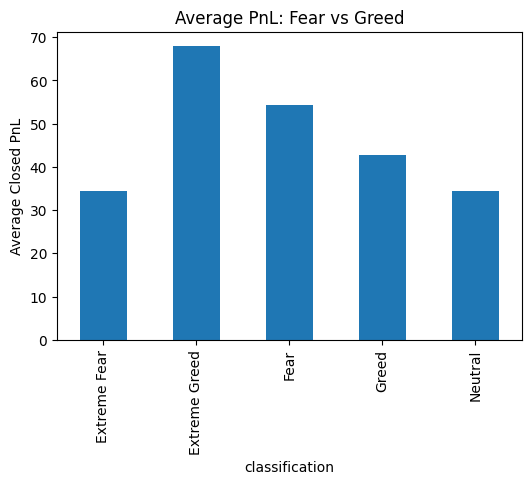

In [79]:
#Fear vs Greedy days Analysis
#Avg PnL Analysis
fear_vs_greed = merged.groupby("classification").agg(
    Avg_PnL=("Closed PnL", "mean"),
    Median_PnL=("Closed PnL", "median"),
    Total_PnL=("Closed PnL", "sum"),
    Trades=("Trade ID", "count")
).reset_index()

fear_vs_greed
import matplotlib.pyplot as plt

fear_vs_greed.plot(
    x="classification",
    y="Avg_PnL",
    kind="bar",
    legend=False,
    figsize=(6,4)
)

plt.title("Average PnL: Fear vs Greed")
plt.ylabel("Average Closed PnL")
plt.show()


classification
Extreme Fear     37.060748
Extreme Greed    46.494299
Fear             42.076750
Greed            38.482794
Neutral          39.699093
Name: Win, dtype: float64


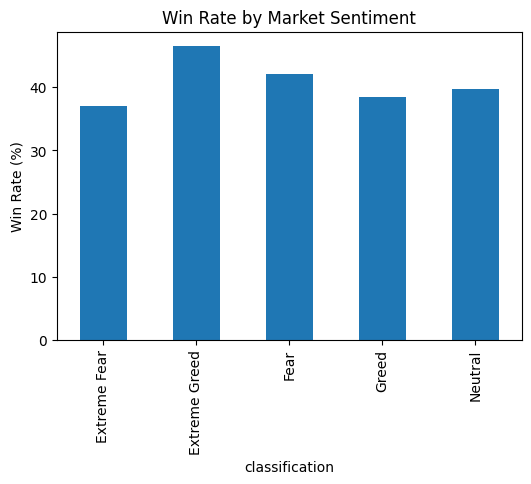

In [80]:
#Win Rate Analysis
merged["Win"] = merged["Closed PnL"] > 0
win_rate = merged.groupby("classification")["Win"].mean() * 100

print(win_rate)
win_rate.plot(kind="bar", figsize=(6,4))

plt.title("Win Rate by Market Sentiment")
plt.ylabel("Win Rate (%)")
plt.show()

In [84]:
#Drawdown Proxy
daily_account = merged.groupby(
    ["Date","Account"]
)["Closed PnL"].sum().reset_index()

drawdown = daily_account.groupby("Account")["Closed PnL"].min()

drawdown.describe()

count        32.000000
mean     -42370.566942
std       72457.016801
min     -358963.139984
25%      -58078.449590
50%      -10696.565415
75%       -1452.051170
max           0.000000
Name: Closed PnL, dtype: float64

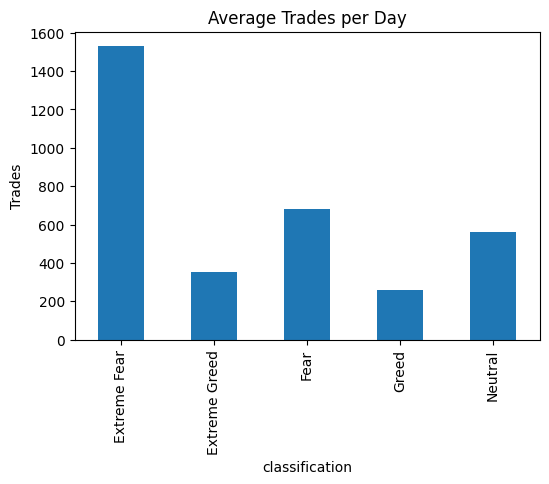

In [ ]:
#Trader Behaviour Analysis
#Trade Frequency
trade_frequency = merged.groupby(
    ["Date","classification"]
).size().reset_index(name="Trades")

trade_frequency.groupby("classification")["Trades"].mean().plot(
    kind="bar",
    figsize=(6,4)
)

plt.title("Average Trades per Day")
plt.ylabel("Trades")
plt.show()

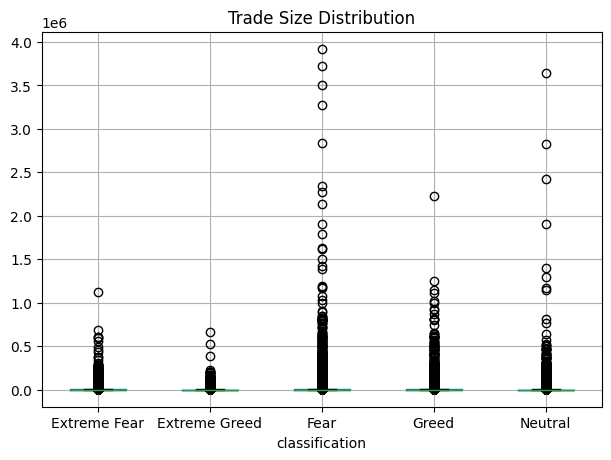

In [87]:
#Position Size
merged.groupby("classification")["Size USD"].mean()
merged.boxplot(
    column="Size USD",
    by="classification",
    figsize=(7,5)
)

plt.title("Trade Size Distribution")
plt.suptitle("")
plt.show()

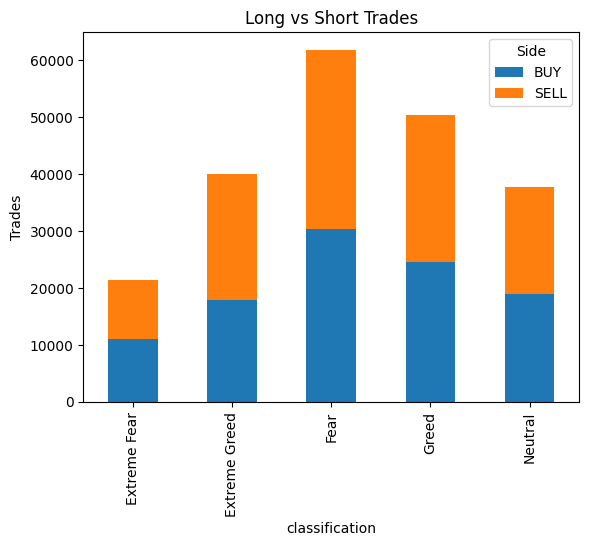

In [88]:
#Long vs Short
merged["Side"].value_counts()
side = pd.crosstab(
    merged["classification"],
    merged["Side"]
)

side
side.plot(kind="bar", stacked=True)

plt.title("Long vs Short Trades")
plt.ylabel("Trades")
plt.show()

In [91]:
#Segmenting Traders
#Frequent vs Infrequent
trade_counts = merged.groupby("Account").size()

threshold = trade_counts.median()

segments = pd.DataFrame({
    "Trades": trade_counts
})

segments["Frequency"] = segments["Trades"].apply(
    lambda x: "Frequent" if x >= threshold else "Infrequent"
)

#Performance
segment_perf = merged.merge(
    segments,
    left_on="Account",
    right_index=True
)

segment_perf.groupby("Frequency")["Closed PnL"].mean()

Frequency
Frequent      42.493421
Infrequent    96.943024
Name: Closed PnL, dtype: float64

In [93]:
#Consistent Winners
wins = merged.groupby("Account")["Win"].mean()

winner_segment = pd.DataFrame({
    "WinRate": wins
})

winner_segment["Type"] = winner_segment["WinRate"].apply(
    lambda x: "Consistent Winner"
    if x >= 0.6
    else "Inconsistent"
)
merged2 = merged.merge(
    winner_segment,
    left_on="Account",
    right_index=True
)

merged2.groupby("Type")["Closed PnL"].mean()

Type
Consistent Winner    38.319560
Inconsistent         49.261483
Name: Closed PnL, dtype: float64

In [95]:
#Large vs Small Traders
size = merged.groupby("Account")["Size USD"].mean()

median_size = size.median()

size_segment = pd.DataFrame({
    "AvgSize": size
})

size_segment["Segment"] = size_segment["AvgSize"].apply(
    lambda x: "Large" if x >= median_size else "Small"
)
merged3 = merged.merge(
    size_segment,
    left_on="Account",
    right_index=True
)

merged3.groupby("Segment")["Closed PnL"].mean()

Segment
Large    99.587777
Small    25.149651
Name: Closed PnL, dtype: float64

In [97]:
#Statistical Test
from scipy.stats import ttest_ind

fear = merged.loc[
    merged["classification"] == "Fear",
    "Closed PnL"
]

greed = merged.loc[
    merged["classification"] == "Greed",
    "Closed PnL"
]

t_stat, p_value = ttest_ind(
    fear,
    greed,
    equal_var=False
)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_value:.4f}")

T-statistic: 1.851
P-value: 0.0642


In [ ]:
#Mann Whitney Test
from scipy.stats import mannwhitneyu

fear = merged.loc[
    merged["classification"] == "Fear",
    "Closed PnL"
]

greed = merged.loc[
    merged["classification"] == "Greed",
    "Closed PnL"
]

u_stat, p = mannwhitneyu(
    fear,
    greed,
    alternative="two-sided"
)

print("U-statistic:", u_stat)
print("P-value:", p)

U-statistic: 1643204000.5
P-value: 1.3045873858600704e-68


In [99]:
fear = merged.loc[merged["classification"] == "Fear", "Closed PnL"]
greed = merged.loc[merged["classification"] == "Greed", "Closed PnL"]

print("Fear Median :", fear.median())
print("Greed Median:", greed.median())

print("Fear Mean :", fear.mean())
print("Greed Mean:", greed.mean())
merged.groupby("classification")["Closed PnL"].describe()

Fear Median : 0.0
Greed Median: 0.0
Fear Mean : 54.29039962549929
Greed Mean: 42.74355948851957


,count,mean,std,min,25%,50%,75%,max
classification,,,,,,,,
Extreme Fear,21400.0,34.537862,1136.056091,-31036.69194,0.0,0.0,5.635032,115287.00000
Extreme Greed,39992.0,67.892861,766.828294,-10259.46800,0.0,0.0,10.028709,44223.45187
Fear,61837.0,54.290400,935.355438,-35681.74723,0.0,0.0,5.590856,135329.09010
Greed,50303.0,42.743559,1116.028390,-117990.10410,0.0,0.0,4.944105,74530.52371
Neutral,37686.0,34.307718,517.122220,-24500.00000,0.0,0.0,3.995795,48504.09555


In [101]:
merged["Outcome"] = merged["Closed PnL"].apply(
    lambda x: "Profit" if x > 0 else ("Loss" if x < 0 else "Break-even")
)

pd.crosstab(
    merged["classification"],
    merged["Outcome"],
    normalize="index"
) * 100

Outcome,Break-even,Loss,Profit
classification,,,
Extreme Fear,51.373832,11.565421,37.060748
Extreme Greed,47.857071,5.648630,46.494299
Fear,51.795850,6.127399,42.076750
Greed,49.951295,11.565911,38.482794
Neutral,51.814998,8.485910,39.699093


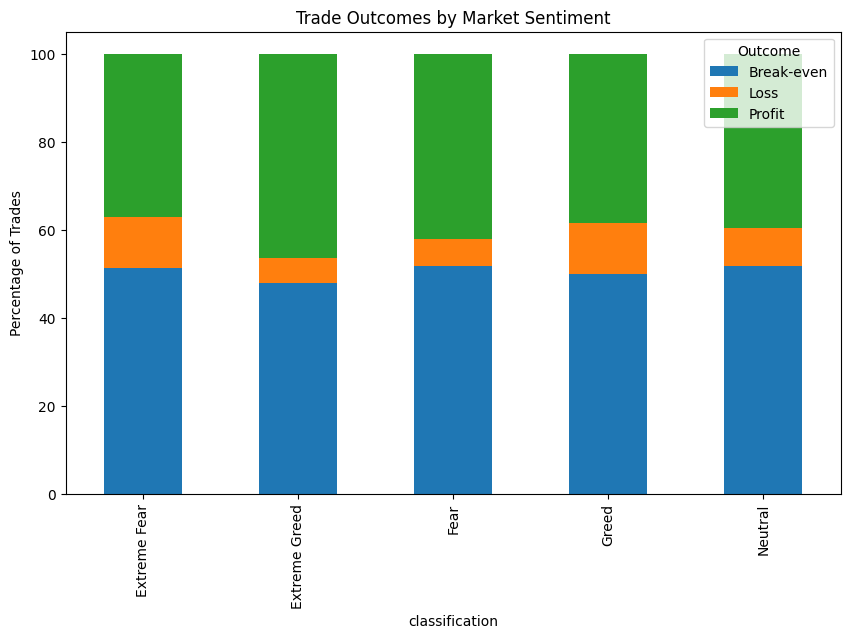

In [102]:
#Visualizations
outcome_pct = (
    pd.crosstab(
        merged["classification"],
        merged["Outcome"],
        normalize="index"
    ) * 100
)

outcome_pct.plot(
    kind="bar",
    stacked=True,
    figsize=(10,6)
)

plt.ylabel("Percentage of Trades")
plt.title("Trade Outcomes by Market Sentiment")
plt.legend(title="Outcome")
plt.show()

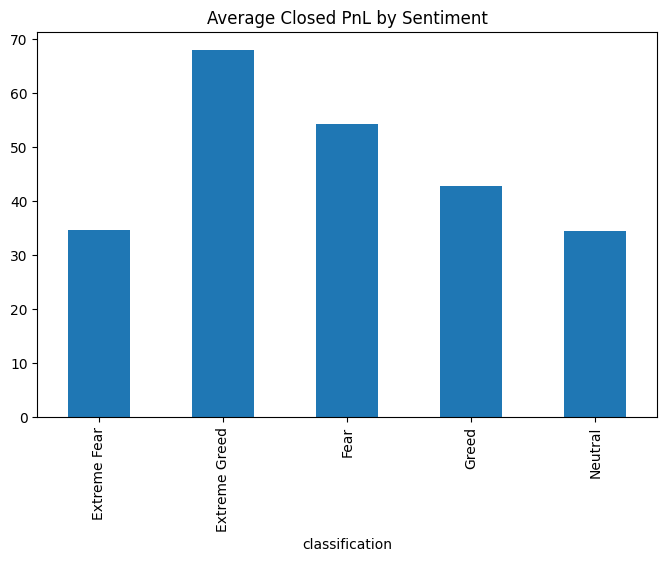

In [104]:
merged.groupby("classification")["Closed PnL"].mean().plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Average Closed PnL by Sentiment")
plt.show()

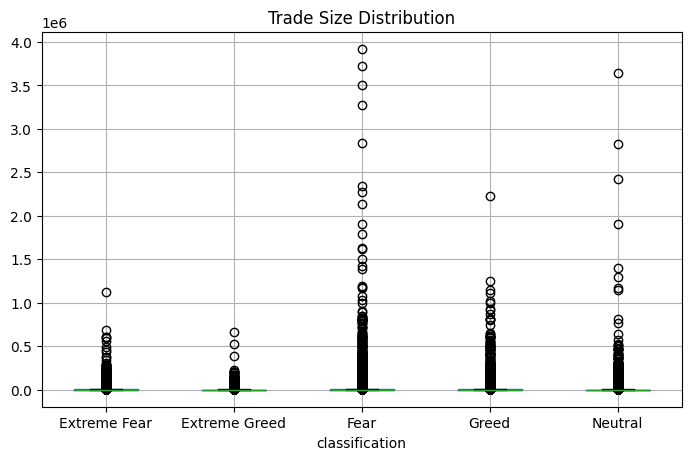

In [105]:
merged.boxplot(
    column="Size USD",
    by="classification",
    figsize=(8,5)
)

plt.suptitle("")
plt.title("Trade Size Distribution")
plt.show()